In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kalepy as kale

import holodeck as holo
import holodeck.sams
from holodeck import utils, plot
from holodeck.constants import MSOL


See [Leja+2020 - A New Census of the 0.2 < z < 3.0 Universe. I. The Stellar Mass Function ](https://ui.adsabs.harvard.edu/abs/2020ApJ...893..111L/abstract)
This notebook converts from the "anchor point" fits, into fits of the redshift-function expansion.  i.e. converting from the parameters given in [Leja+2020] Fig.3, into the coefficients for their Eq.17.

See [Leja+2020 - A New Census of the 0.2 < z < 3.0 Univers. I. The Stellar Mass Function ](https://ui.adsabs.harvard.edu/abs/2020ApJ...893..111L/abstract)
This notebook convers from the "anchor point" fits, into fits of the redshift-function expansion. I.e., it converts from the parameters given in [Leja+2020] Fig. 3 into the coefficients for their Eq. 17.

# GSMF

## the function itself

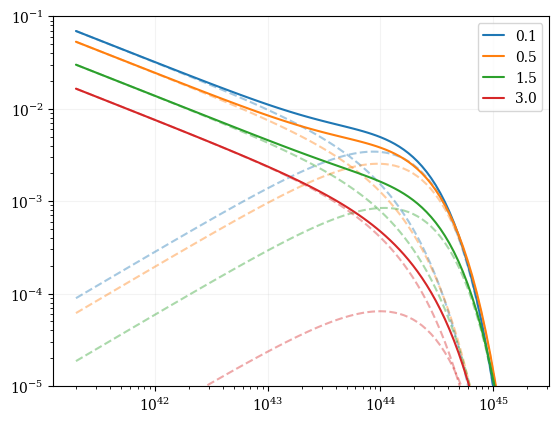

In [2]:
gsmf = holo.sams.components.GSMF_Double_Schechter()

mstar = np.logspace(8, 12, 100) * MSOL

for redz in [0.1, 0.5, 1.5, 3.0]:

    phi = gsmf(mstar, redz)
    cc, = plt.loglog(mstar, phi, label=redz)
    cc = cc.get_color()

    phi = gsmf._gsmf_one(mstar, redz)
    plt.loglog(mstar, phi, ls='--', color=cc, alpha=0.4)
    phi = gsmf._gsmf_two(mstar, redz)
    plt.loglog(mstar, phi, ls='--', color=cc, alpha=0.4)

ax = plt.gca()
ylim = [1e-5, 1e-1]
ax.set(ylim=ylim)
ax.legend()
plt.show()

## used in SAM

16:05:22 INFO : No galaxy pair-fraction given, using galaxy merger-rate. [sam.py:__init__]
16:05:22 INFO : No GMT was provided, cannot calculate Galaxy-Merger based stalling. [sam.py:static_binary_density]
16:05:22 INFO : Adding MMbulge scatter (2.8000e-01) [sam.py:static_binary_density]
16:05:22 INFO : 	dens bef: (0.00e+00, 0.00e+00, 3.22e-87, 4.59e-03, 4.46e-01, 2.30e+00, 1.06e+02) [sam.py:static_binary_density]
16:05:22 INFO : Scatter added after 0.509279 sec [sam.py:static_binary_density]
16:05:22 INFO : 	dens aft: (1.39e-60, 1.62e-12, 1.35e-09, 7.05e-03, 6.46e-01, 2.23e+00, 9.40e+01) [sam.py:static_binary_density]
16:05:22 INFO : 	mass: 1.15e+00 ==> 1.49e+00 || change = 2.9764e-01 [sam.py:static_binary_density]
16:05:22 ERROR : Warning, significant change in number-mass!  mass: 1.15e+00 ==> 1.49e+00 || change = 2.9764e-01 [sam.py:static_binary_density]
16:05:22 INFO : `redz_prime` not calculated in SAM.  Setting to `redz` (initial) values. [sam.py:gwb]
16:05:27 INFO : No galaxy pa

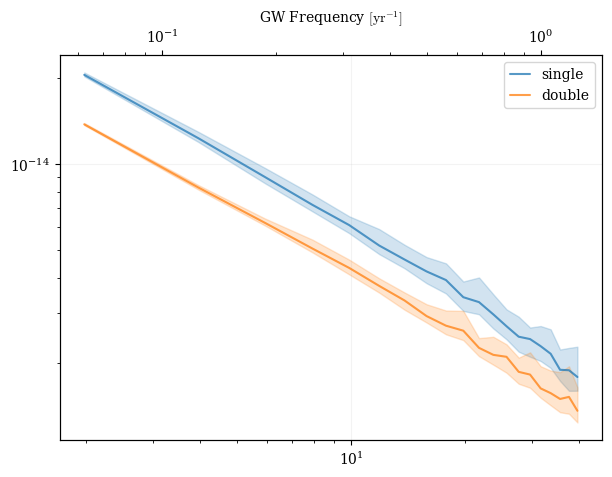

In [3]:
SHAPE = 30
NFREQ = 20
NREALS = 100
fobs_cents, fobs_edges = utils.pta_freqs(num=NFREQ)

# calculate GWB using double-schechter GSMF
gsmf_double = holo.sams.components.GSMF_Double_Schechter()
sam_double = holo.sams.Semi_Analytic_Model(gsmf=gsmf_double, shape=SHAPE)
hc_ss, hc_bg = sam_double.gwb(fobs_edges, realize=NREALS)
gwb_double = np.sqrt(hc_bg**2 + np.sum(hc_ss**2, axis=-1))

# calculate GWB using standard (single) schechter GSMF
gsmf_single = holo.sams.components.GSMF_Schechter()
sam_single = holo.sams.Semi_Analytic_Model(gsmf=gsmf_single, shape=SHAPE)
hc_ss, hc_bg = sam_single.gwb(fobs_edges, realize=NREALS)
gwb_single = np.sqrt(hc_bg**2 + np.sum(hc_ss**2, axis=-1))

# plot both GWBs
fig, ax = plot.figax()
plot.draw_gwb(ax, fobs_cents*1e9, gwb_single, plot=dict(label='single'), nsamp=None, fracs=[0.5])
plot.draw_gwb(ax, fobs_cents*1e9, gwb_double, plot=dict(label='double'), nsamp=None, fracs=[0.5])

plot._twin_yr(ax)
ax.legend()

plt.show()


# Covariance Derivation

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Redshift values for anchor points
ZVALS = [0.2, 1.6, 3.0]

def get_cs(yy):
    z1, z2, z3 = ZVALS
    if yy.ndim == 1:
        y1, y2, y3 = yy
    else:
        y1, y2, y3 = yy
    
    # calculate quadratic coefficients (c0, c1, c2)
    tt = (z1 - z3) / (z2 - z1)
    denom = (z2**2 - z1**2) * tt
    denom = z3**2 - z1**2 + denom
    numer = (y3 - y1) + (y2 - y1) * tt
    c2 = numer / denom
    c1 = y2 - y1 - c2*(z2**2 - z1**2)
    c1 /= (z2 - z1)
    c0 = y1 - c2*z1**2 - c1*z1
    return np.array([c0, c1, c2])

# Anchor point data from Leja+2020 Fig 3
pars = {
    'logphi1': [-2.44, -3.08, -4.14],
    'logphi1_err': [0.02, 0.03, 0.1],
    'logphi2': [-2.89, -3.29, -3.51],
    'logphi2_err': [0.04, 0.03, 0.03],
    'logmstar': [10.79, 10.88, 10.84],
    'logmstar_err': [0.02, 0.02, 0.04],
}

NUM = 100000
def propagate_uncertainties(par_name):
    yave = np.array(pars[par_name])
    yerr = np.array(pars[par_name + "_err"])
    yy_samples = np.random.normal(yave[:, np.newaxis], yerr[:, np.newaxis], size=(3, NUM))
    cs_samples = get_cs(yy_samples)
    return np.mean(cs_samples, axis=1), np.std(cs_samples, axis=1)


all_means = []
all_sigmas = []
for name in ['logphi1', 'logphi2', 'logmstar']:
    m, s = propagate_uncertainties(name)
    all_means.extend(m)
    all_sigmas.extend(s)
# Add alpha1, alpha2 (11D total)
all_means.extend([-0.40, -1.53])
all_sigmas.extend([0.07, 0.015])
final_means = np.array(all_means)
final_sigmas = np.array(all_sigmas)
# Construct Correlation Matrix (Rho)
n = 11
rho = np.eye(n)
rho[3, 9]  =  0.85  # log(phi2)c0 vs alpha1
rho[4, 5]  =  0.90  # log(phi2)c1 vs log(phi2)c2
rho[9, 10] =  0.60  # alpha1 vs alpha2
rho[6, 9]  = -0.70  # log(M*)c0 vs alpha1
rho[0, 3]  = -0.40  # log(phi1)c0 vs log(phi2)c0
rho[2, 4]  = -0.50  # log(phi1)c2 vs log(phi2)c1
rho = (rho + rho.T) - np.eye(n)
# Construct and Repair Covariance Matrix
cov = np.outer(final_sigmas, final_sigmas) * rho
def repair_covariance(m):
    m = (m + m.T) / 2
    eigval, eigvec = np.linalg.eigh(m)
    eigval = np.maximum(eigval, 1e-10)
    return eigvec @ np.diag(eigval) @ eigvec.T
cov_fixed = repair_covariance(cov)
print("Final 11D Means:\n", final_means)
print("\nFinal Fixed Covariance Matrix (11x11):\n", repr(cov_fixed))

Final 11D Means:
 [-2.38278427 -0.26440941 -0.10705001 -2.81831716 -0.36812427  0.04585252
 10.76640299  0.12402037 -0.03316537 -0.4        -1.53      ]

Final Fixed Covariance Matrix (11x11):
 array([[ 7.74058387e-04, -2.40714767e-20,  5.68097254e-21,
        -4.94535600e-04,  8.01869358e-21, -4.92717092e-22,
        -5.42635754e-05,  2.84070483e-36, -6.11977250e-37,
        -4.71183663e-05,  4.49630103e-05],
       [-2.40714767e-20,  5.05082878e-03, -1.96972032e-19,
         4.24492584e-19,  6.21086423e-20,  5.96203823e-19,
        -5.68754834e-19,  1.80034659e-19,  1.79716367e-23,
        -1.53627101e-19,  5.58184365e-19],
       [ 5.68097254e-21, -1.96972032e-19,  9.13448734e-04,
         2.07384617e-19, -1.04187030e-03, -7.53554102e-06,
        -1.62393817e-19,  5.10024635e-20, -3.45700158e-23,
         6.96931949e-19, -8.46809462e-20],
       [-4.94535600e-04,  4.24492584e-19,  2.07384617e-19,
         2.60573393e-03,  2.13663777e-21,  9.80042702e-22,
        -1.17597547e-04,  6.

## Visualizing the Fits

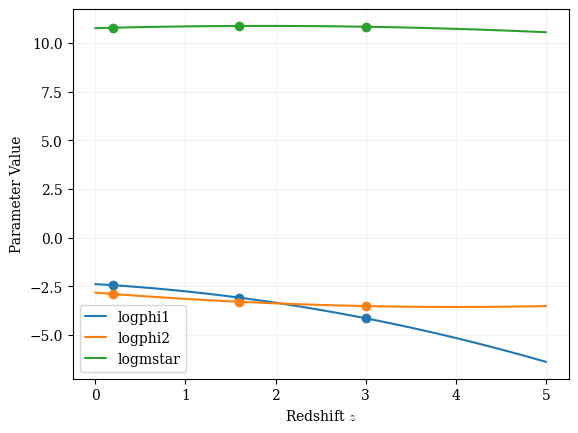

In [7]:
def use_cs(zz, cc):
    return cc[0] + cc[1]*zz + cc[2]*(zz**2)

fig, ax = plt.subplots()
redz = np.linspace(0.0, 5.0, 100)
for i, par in enumerate(['logphi1', 'logphi2', 'logmstar']):
    par_cs = final_means[i*3 : (i+1)*3]
    yy = use_cs(redz, par_cs)
    ax.plot(redz, yy, label=par)
    # Plot the original anchor points for comparison
    ax.scatter(ZVALS, pars[par], color=f"C{i}")

ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Parameter Value')
ax.legend()
plt.show()


## Consistency and Distribution Check
We now check the distributions of the derived coefficients to ensure they are approximately Gaussian and centered correctly.

   logphi1 : c0 -- $ -2.383 \pm 0.028$
   logphi1 : c1 -- $ -0.264 \pm 0.072$
   logphi1 : c2 -- $ -0.107 \pm 0.030$
   logphi2 : c0 -- $ -2.818 \pm 0.050$
   logphi2 : c1 -- $ -0.369 \pm 0.069$
   logphi2 : c2 -- $ +0.046 \pm 0.020$
  logmstar : c0 -- $+10.767 \pm 0.025$
  logmstar : c1 -- $ +0.124 \pm 0.044$
  logmstar : c2 -- $ -0.033 \pm 0.015$


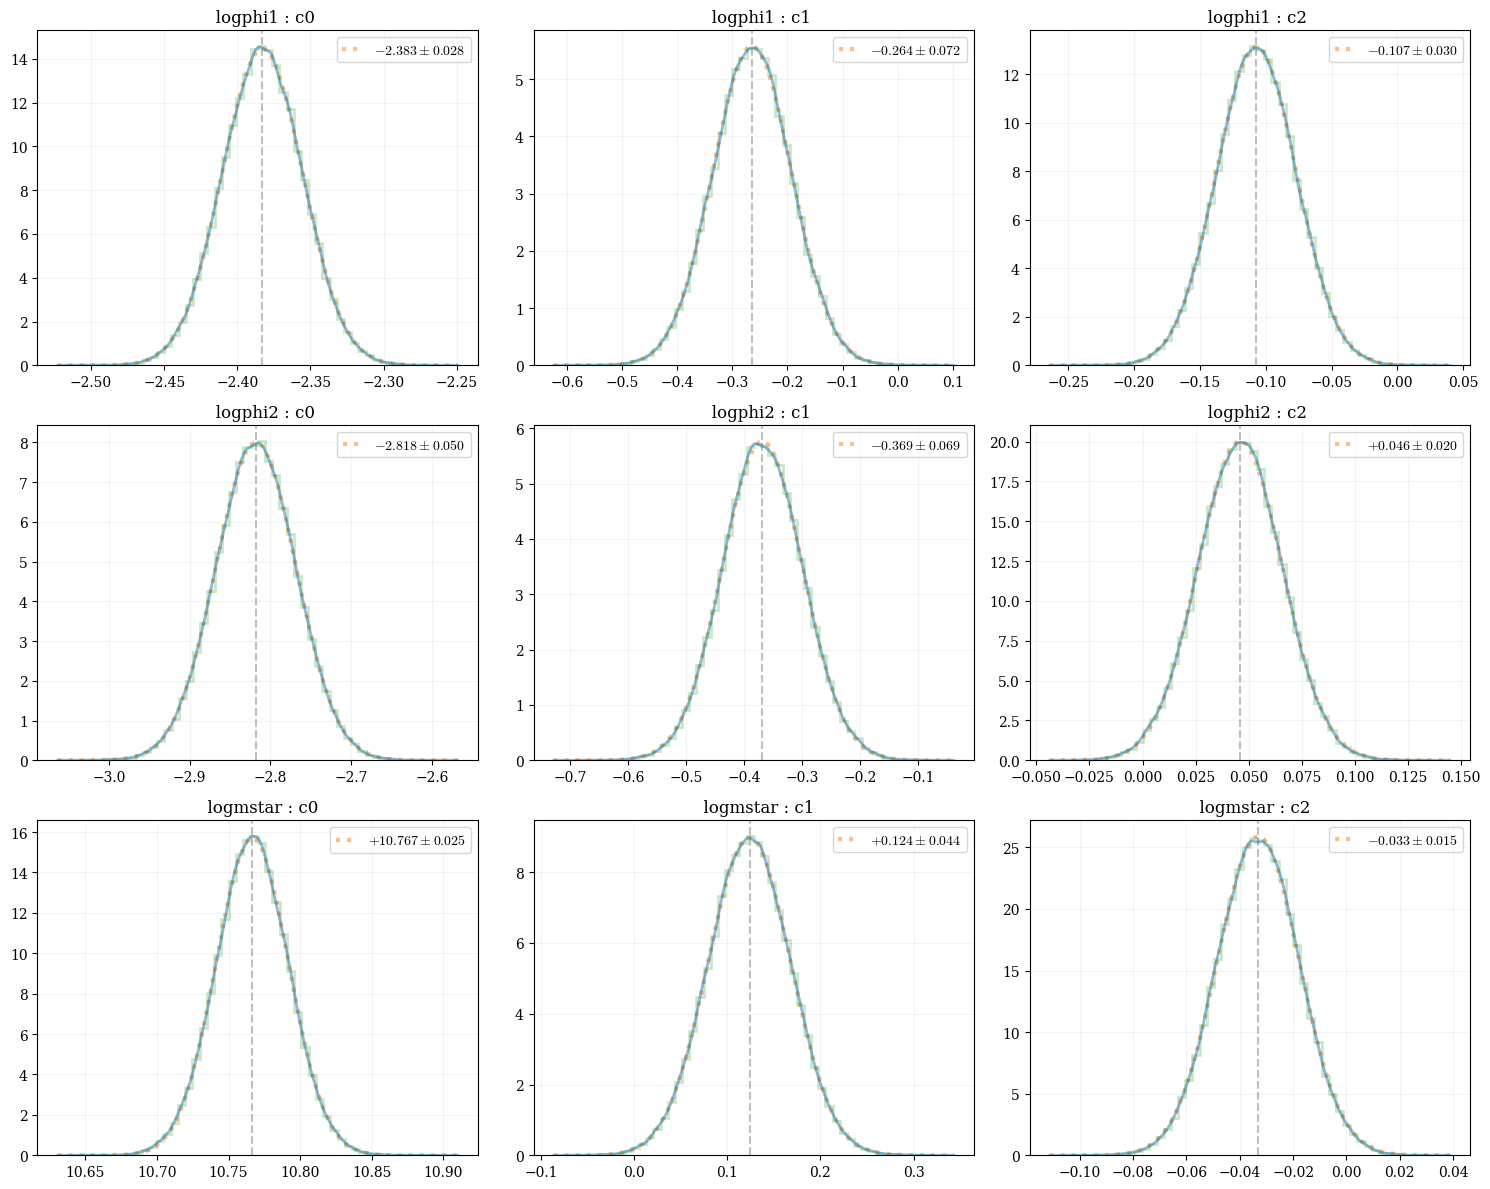

In [9]:
NUM = 1e5

# This checks that our sampling correctly recovers the anchor points and 
# visualizes the distribution of the derived quadratic coefficients.
fig, axes = plt.subplots(figsize=[15, 12], ncols=3, nrows=3)

for jj, par in enumerate(['logphi1', 'logphi2', 'logmstar']):
    axrow = axes[jj]

    yave = np.array(pars[par])
    yerr = np.array(pars[par + "_err"])

    # Sample from the anchor points
    yy = np.random.normal(yave[:, np.newaxis], yerr[:, np.newaxis], size=(3, int(NUM)))

    # Get the coefficients for all samples
    cs = get_cs(yy)
    cave = get_cs(yave)

    for ii, ax in enumerate(axrow):
        title = f"{par:>10s} : c{ii}"
        ax.set_title(title)
        ax.axvline(cave[ii], color='k', ls='--', alpha=0.25)

        # Plot density
        aa, bb = kale.density(cs[ii], probability=True)
        ax.plot(aa, bb, alpha=0.5, zorder=10, lw=2.0)

        # Fit a Gaussian to the sample distribution to check mean/sigma
        ave = np.mean(cs[ii])
        std = np.std(cs[ii])
        popt, pcov = holo.utils.fit_gaussian(aa, bb, guess=[bb.max(), ave, std])

        # Plot the fit
        bb_fit = holo.utils._func_gaussian(aa, *popt)
        lab = f"${popt[1]:+7.3f} \\pm {popt[2]:.3f}$"
        print(title + " -- " + lab)
        ax.plot(aa, bb_fit, alpha=0.5, ls=':', lw=3.0, label=lab)

        # Histogram for comparison
        ax.hist(cs[ii], bins=50, histtype='step', density=True, alpha=0.25, lw=2.0)

        ax.legend()

plt.tight_layout()
plt.show()


## Repairing the Covariance Matrix
Numerical propagation can sometimes result in a correlation matrix that isn't strictly positive-semidefinite. We use `repair_covariance` to ensure stability.

In [12]:
from holodeck.utils import repair_covariance
# Repair the covariance matrix to ensure it is symmetric and PSD
# (Using the utility function we added to holodeck/utils.py)
cov_fixed = utils.repair_covariance(cov)

print("Final 11D Means:\n", list(final_means))
print("\nFinal Fixed Covariance Matrix (11x11):\n", repr(cov_fixed))

# Verification
print("\nMatrix is symmetric:", np.allclose(cov_fixed, cov_fixed.T))
print("Matrix is PSD:", np.all(np.linalg.eigvalsh(cov_fixed) > 0))


Final 11D Means:
 [np.float64(-2.3827842651809514), np.float64(-0.2644094115723517), np.float64(-0.10705001032888115), np.float64(-2.81831715743838), np.float64(-0.3681242701328935), np.float64(0.045852522167938135), np.float64(10.766402987958239), np.float64(0.12402037377450616), np.float64(-0.033165371590352155), np.float64(-0.4), np.float64(-1.53)]

Final Fixed Covariance Matrix (11x11):
 array([[ 7.74058387e-04, -2.40714767e-20,  5.68097254e-21,
        -4.94535600e-04,  8.01869358e-21, -4.92717092e-22,
        -5.42635754e-05,  2.84070483e-36, -6.11977250e-37,
        -4.71183663e-05,  4.49630103e-05],
       [-2.40714767e-20,  5.05082878e-03, -1.96972032e-19,
         4.24492584e-19,  6.21086423e-20,  5.96203823e-19,
        -5.68754834e-19,  1.80034659e-19,  1.79716367e-23,
        -1.53627101e-19,  5.58184365e-19],
       [ 5.68097254e-21, -1.96972032e-19,  9.13448734e-04,
         2.07384617e-19, -1.04187030e-03, -7.53554102e-06,
        -1.62393817e-19,  5.10024635e-20, -3.45

## Final Constants for `param_spaces.py`
These are the verified values for the covariant GSMF parameter space.

In [15]:
GSMF_COV_NAMES = [
    "gsmf_log10_phi_one_z0", "gsmf_log10_phi_one_z1", "gsmf_log10_phi_one_z2",
    "gsmf_log10_phi_two_z0", "gsmf_log10_phi_two_z1", "gsmf_log10_phi_two_z2",
    "gsmf_log10_mstar_z0", "gsmf_log10_mstar_z1", "gsmf_log10_mstar_z2",
    "gsmf_alpha_one", "gsmf_alpha_two"
]
print("GSMF_COV_NAMES =", GSMF_COV_NAMES)
print("GSMF_COV_MEANS =", list(np.round(final_means, 4)))
print("GSMF_COV_MATRIX =", np.round(cov_fixed, 6).tolist())


GSMF_COV_NAMES = ['gsmf_log10_phi_one_z0', 'gsmf_log10_phi_one_z1', 'gsmf_log10_phi_one_z2', 'gsmf_log10_phi_two_z0', 'gsmf_log10_phi_two_z1', 'gsmf_log10_phi_two_z2', 'gsmf_log10_mstar_z0', 'gsmf_log10_mstar_z1', 'gsmf_log10_mstar_z2', 'gsmf_alpha_one', 'gsmf_alpha_two']
GSMF_COV_MEANS = [np.float64(-2.3828), np.float64(-0.2644), np.float64(-0.1071), np.float64(-2.8183), np.float64(-0.3681), np.float64(0.0459), np.float64(10.7664), np.float64(0.124), np.float64(-0.0332), np.float64(-0.4), np.float64(-1.53)]
GSMF_COV_MATRIX = [[0.000774, -0.0, 0.0, -0.000495, 0.0, -0.0, -5.4e-05, 0.0, -0.0, -4.7e-05, 4.5e-05], [-0.0, 0.005051, -0.0, 0.0, 0.0, 0.0, -0.0, 0.0, 0.0, -0.0, 0.0], [0.0, -0.0, 0.000913, 0.0, -0.001042, -8e-06, -0.0, 0.0, -0.0, 0.0, -0.0], [-0.000495, 0.0, 0.0, 0.002606, 0.0, 0.0, -0.000118, 0.0, -0.0, 0.002868, 9.7e-05], [0.0, 0.0, -0.001042, 0.0, 0.004794, 0.001234, 0.0, 0.0, -0.0, -0.0, 0.0], [-0.0, 0.0, -8e-06, 0.0, 0.001234, 0.000416, 0.0, -0.0, 0.0, -0.0, 0.0], [-5.4e-05